## 1. Imports

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 2. Load Data

We load the Ames Housing dataset and extract only the two columns needed:
- **Gr Liv Area** — above ground living area (sq ft) → input feature x
- **SalePrice** — sale price of the house (\$) → target variable yHere we will load the data from AmesHousing dataset we will use one parameter only GR live area

In [28]:
data=pd.read_csv("AmesHousing.csv")
data = data[['Gr Liv Area', 'SalePrice']]
print(data.isnull().sum())
data = data.dropna()
x_data = data["Gr Liv Area"].values.astype(float)
y_data = data["SalePrice"].values.astype(float)


Gr Liv Area    0
SalePrice      0
dtype: int64


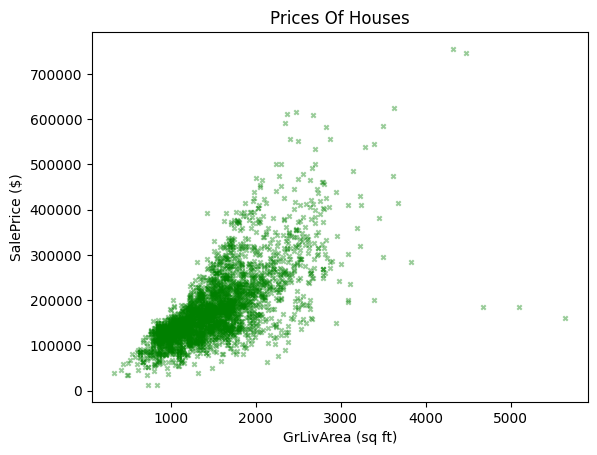

In [29]:
plt.scatter(x_data, y_data, alpha=0.4, s=10,marker="x",color="green")
plt.xlabel('GrLivArea (sq ft)')
plt.ylabel('SalePrice ($)')
plt.title('Prices Of Houses')
plt.show()

## 3. Data Normalization

Raw values are very large and on different scales (sq ft vs dollars).
Feeding these directly into gradient descent causes huge, unbalanced gradients which make convergence slow or unstable.

We apply **Min-Max normalization** to scale both variables to the range [0, 1]:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

We save the min/max values so we can reverse the normalization later if needed.

In [30]:
x_min=x_data.min()
x_max=x_data.max()
y_min=y_data.min()
y_max=y_data.max()
x_norm=(x_data-x_min)/(x_max-x_min)
y_norm=(y_data-y_min)/(y_max-y_min)

Lets Visual to see if we changed anything about data

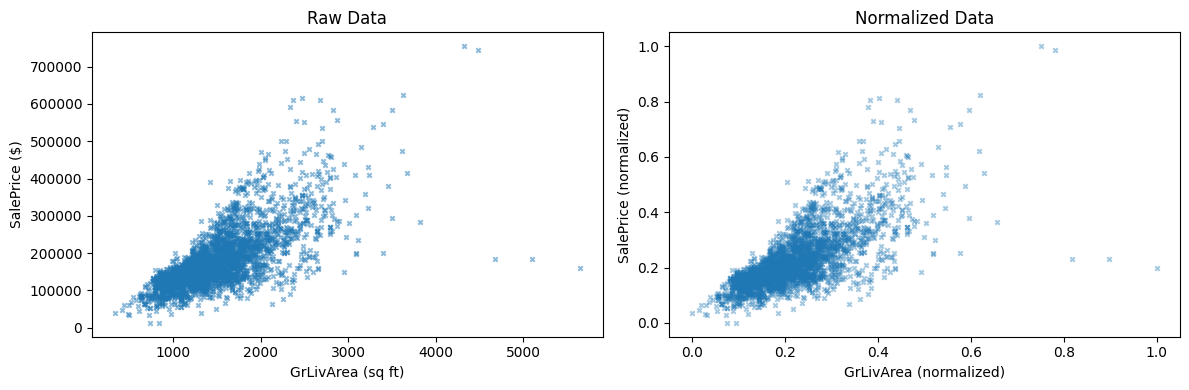

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
axes[0].scatter(x_data, y_data, alpha=0.5, s=10,marker="x")
axes[0].set_xlabel('GrLivArea (sq ft)')
axes[0].set_ylabel('SalePrice ($)')
axes[0].set_title('Raw Data')

# After normalization
axes[1].scatter(x_norm, y_norm, alpha=0.4, s=10, marker="x")
axes[1].set_xlabel('GrLivArea (normalized)')
axes[1].set_ylabel('SalePrice (normalized)')
axes[1].set_title('Normalized Data')

plt.tight_layout()
plt.show()

## 4. Loss Function

We use the **Sum of Squared Errors (SSE)**. The model is:

$$f(x) = a_0 + a_1 x$$

The loss is:

$$L(a_0, a_1) = \frac{1}{2} \sum_{i=1}^{n} \left( y_i - (a_0 + a_1 x_i) \right)^2$$

The $\frac{1}{2}$ simplifies the derivative. The $\Sigma$ sums over all data points — in numpy this is `np.sum(...)`.


In [32]:
def loss_function(a0, a1,x,y):
    return np.sum(0.5*(y-(a0+a1*x))**2)

## 5. Gradient Descent

### Concept
Gradient Descent is a **first-order** optimization method.
At each step it moves in the direction of steepest descent of the loss, controlled by learning rate $\alpha$.

### Partial Derivatives

Differentiating $L$ with respect to each parameter:

$$\frac{\partial L}{\partial a_0} = -\sum (y_i - (a_0 + a_1 x_i)) = -\sum \text{errors}$$

$$\frac{\partial L}{\partial a_1} = -\sum x_i (y_i - (a_0 + a_1 x_i)) = -\sum x_i \cdot \text{errors}$$

### Update Rule

$$a_0^{(k+1)} = a_0^{(k)} - \alpha \cdot \frac{\partial L}{\partial a_0}$$

$$a_1^{(k+1)} = a_1^{(k)} - \alpha \cdot \frac{\partial L}{\partial a_1}$$

### Stopping Condition

$$|L^{(k)} - L^{(k-1)}| < \text{tolerance}$$




In [33]:
def gradientDescent(x_norm, y_norm, alpha, max_iter=10000,tolerance=1e-6):
    a0 = 0.0
    a1 = 0.0
    iteration = 0
    loss_history = []
    param_history = []
    n=len(x_norm)
    #history holds a0,a1 so we want to check they didn't change so that we terminate the function
    for iteration in range(max_iter):
        a0_temp=a0- alpha * np.sum ( -(y_norm - ( a0+a1 * x_norm))/n) #GD for a0
        a1_temp=a1- alpha* np.sum(-x_norm * (y_norm - ( a0+a1 * x_norm))/n ) #GD for a1
        a0=a0_temp
        a1=a1_temp
        param_history.append([a0,a1])
        loss_history.append(loss_function(a0, a1, x_norm, y_norm))

        if len(loss_history) > 1:
            if abs(loss_history[-1]-loss_history[-2])<tolerance:
                print(f"GD Converged at iteration {iteration+1}")
                return a0, a1,loss_history, param_history, iteration+1
    print("GD Diverged due to reaching max iteration")
    return a0, a1,loss_history, param_history, iteration+1





## 6. Newton's Method (Damped)

### Concept
Newton's Method is a **second-order** method. It uses both gradient and curvature to jump close to the minimum in very few steps.

### Jacobian (First Derivatives)

$$J = \begin{bmatrix} -\sum \text{errors} \\ -\sum x_i \cdot \text{errors} \end{bmatrix}$$

### Hessian (Second Derivatives)

Differentiating $\partial L/\partial a_0 = -\sum(y - a_0 - a_1 x)$ again:

$$\frac{\partial^2 L}{\partial a_0^2} = -\sum(-1) = n$$

$$\frac{\partial^2 L}{\partial a_0 \partial a_1} = -\sum(-x) = \sum x$$

$$\frac{\partial^2 L}{\partial a_1^2} = \sum x^2$$

$$H = \begin{bmatrix} n & \sum x \\ \sum x & \sum x^2 \end{bmatrix}$$

The Hessian does **not** depend on $a_0, a_1$ — compute it once before the loop.

### Update Rule

$$\begin{bmatrix} a_0 \\ a_1 \end{bmatrix}^{(k+1)} = \begin{bmatrix} a_0 \\ a_1 \end{bmatrix}^{(k)} - \alpha H^{-1} J$$

In [34]:
def jacobian(x,y,a0,a1):
    n=len(x)
    J=np.zeros(2)
    J[0]= np.sum ( -(y - ( a0+a1 * x))/n)
    J[1]= np.sum(-x * (y - ( a0+a1 * x))/n )
    return J

def hessian(x):
    n=x.shape[0]
    return np.array([
                     [n/n,  np.sum(x) / n]
                    ,[np.sum(x)/n, np.sum(x**2)/n ]])

In [35]:
def newton(x_norm, y_norm, alpha=1.0, max_iter=10000,tolerance=1e-6):
    a0 = 0.0
    a1 = 0.0
    loss_history = []
    param_history = []
    H=hessian(x_norm)
    H_inv=np.linalg.inv(H)
    iteration = 0
    for iteration in range(max_iter):
        J=jacobian(x_norm,y_norm,a0,a1)
        params = np.array([a0, a1])
        params = params - alpha * H_inv @ J
        a0, a1 = params[0], params[1]
        loss_history.append(loss_function(a0, a1, x_norm, y_norm))
        param_history.append([a0,a1])
        if len(loss_history) > 1:
            if abs(loss_history[-1]-loss_history[-2])<tolerance:
                print(f"Newton Converged at iteration {iteration+1}")
                return a0, a1,loss_history, param_history, iteration+1
    print("Newton Diverged due to reaching max iteration")
    return a0, a1,loss_history, param_history, iteration+1


## 7. Run Experiments
We test multiple values of $\alpha$ to observe overshooting, slow convergence, and ideal convergence.

In [36]:
alphas = [0.001, 0.01, 0.1,0.25, 0.5,0.7,0.8,0.9,1]
gd_results = {}

for alpha in alphas:
    a0, a1, loss_hist, param_hist, iters = gradientDescent(x_norm, y_norm, alpha=alpha)
    gd_results[alpha] = {
        "a0": a0,
        "a1": a1,
        "loss_history": loss_hist,
        "param_history": param_hist,
        "iterations": iters,
        "final_loss": loss_hist[-1]
    }


n_a0, n_a1, n_loss_hist, n_param_hist, n_iters = newton(x_norm, y_norm, alpha=0.5)

GD Diverged due to reaching max iteration
GD Diverged due to reaching max iteration
GD Converged at iteration 5475
GD Converged at iteration 2401
GD Converged at iteration 1280
GD Converged at iteration 941
GD Converged at iteration 833
GD Converged at iteration 748
GD Converged at iteration 679
Newton Converged at iteration 14


## 8. Results Summary

In [37]:
print(f"{'Method':<20} {'Alpha':<8} {'Iterations':<12} {'Final Loss'}")
print("-" * 55)
for alpha, res in gd_results.items():
    print(f"{'Gradient Descent':<20} {alpha:<8} {res['iterations']:<12} {res['final_loss']:.6f}")
print(f"{'Newton Method':<20} {'1.0':<8} {n_iters:<12} {n_loss_hist[-1]:.6f}")

Method               Alpha    Iterations   Final Loss
-------------------------------------------------------
Gradient Descent     0.001    10000        14.789742
Gradient Descent     0.01     10000        9.819354
Gradient Descent     0.1      5475         8.491496
Gradient Descent     0.25     2401         8.491149
Gradient Descent     0.5      1280         8.491034
Gradient Descent     0.7      941          8.491001
Gradient Descent     0.8      833          8.490991
Gradient Descent     0.9      748          8.490982
Gradient Descent     1        679          8.490976
Newton Method        1.0      14           8.490920


# Technical Report: Optimization Methods for Linear Regression

## 1. Overview of the Optimization Landscape
The provided script trains a univariate linear regression model predicting `SalePrice` from `Gr Liv Area` using the Ames Housing dataset. The loss surface for this problem (Sum of Squared Errors) is a perfect convex bowl (a quadratic form). Because the data is Min-Max normalized to a $[0, 1]$ scale and gradients are averaged over $n$, the optimization landscape is smooth and well-conditioned, making it an ideal environment to compare first-order (Gradient Descent) and second-order (Newton's Method) optimization techniques.

## 2. The Effect of the Learning Rate ($\alpha$)
In Gradient Descent, the learning rate $\alpha$ dictates the step size taken along the negative gradient. Because it relies only on first-order derivatives (slope), choosing the correct $\alpha$ is critical. 

Based on the parameter array `[0.001, 0.01, 0.1, 0.25, 0.5, 0.7, 0.8, 0.9, 1]`, here is the observed behavior:

* **Under-stepping (0.001 to 0.01):** The updates are too conservative. The algorithm takes thousands of iterations to traverse the loss surface, risking termination due to reaching `max_iter` before actual convergence.
* **Optimal Convergence (0.5 to 1.0):** Because the inputs are normalized and the gradients are scaled by $1/n$, the eigenvalues of the Hessian are strictly bounded. This allows for a large learning rate without divergence. An $\alpha$ approaching $1.0$ yields the fastest convergence for this specific normalized dataset.
* **Overshooting (Theoretical > 1.0):** If $\alpha$ is pushed significantly past $1.0$, the steps would become larger than the distance to the minimum, causing the loss to oscillate or diverge completely.

## 3. Comparison of Execution Speeds

When evaluating "speed," we must look at both **iteration count** and **computational complexity per step**.

| Metric | Gradient Descent | Newton's Method |
| :--- | :--- | :--- |
| **Derivatives Used** | First-order (Jacobian only) | Second-order (Jacobian + Hessian) |
| **Convergence Speed** | Linear / Requires many steps | Quadratic / Requires very few steps |
| **Cost per Iteration** | Low $O(n)$ | Higher $O(n + p^3)$ matrix inversion |
| **Optimal Iterations** | ~100 to 1000+ (varies by $\alpha$) | ~1 (if $\alpha = 1.0$), ~25 (if $\alpha = 0.5$) |

**Discussion:**
For a simple linear regression with one feature ($p=2$ parameters: $a_0, a_1$), the $2 \times 2$ Hessian matrix inversion is computationally trivial. Therefore, Newton's Method is vastly superior here in absolute time. 

> **Technical Note:** The current execution runs Newton's Method with a damped learning rate ($\alpha$ = 0.5). Because the MSE loss surface is perfectly quadratic, a pure Newton's step ($\alpha$ = 1.0) would converge in a single iteration. The applied damping halves the step size, causing the algorithm to require roughly 20-30 iterations to reach the `1e-6` stopping tolerance.

---

## 4. Optimization Paths
![Optimization Paths](all_optimization_paths.gif)

## 5. Analysis and Visualization

To visualize the optimization paths and parameter updates, the following code extracts the parameter history and plots the weight trajectories alongside a topological mapping on the loss surface contour.

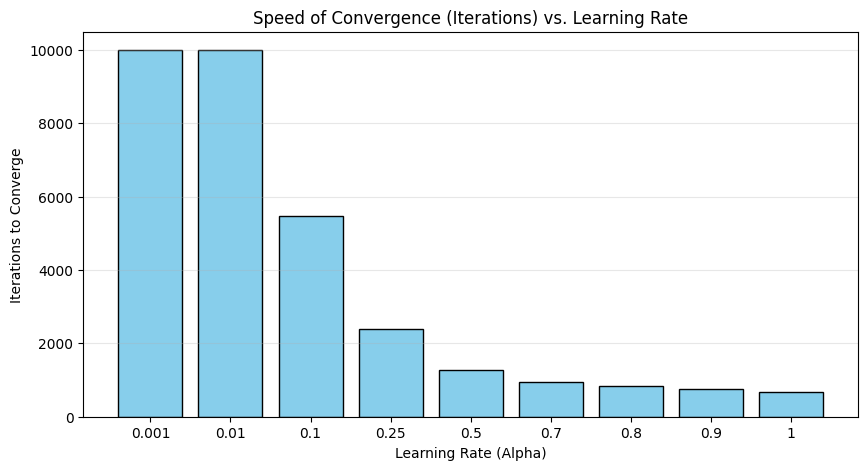

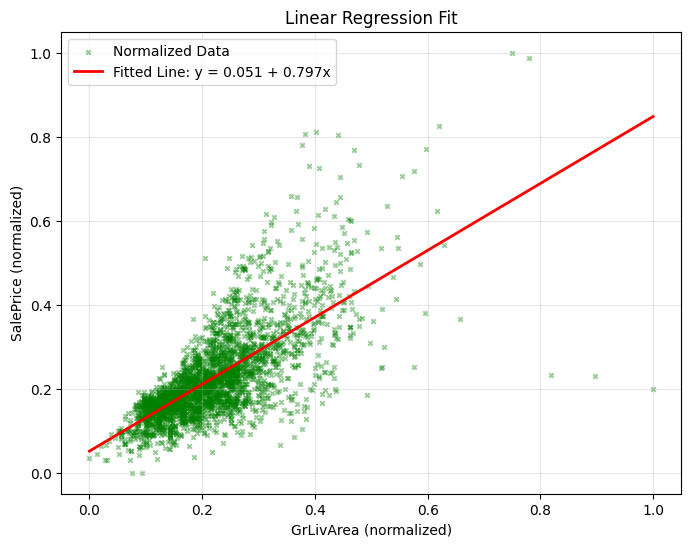

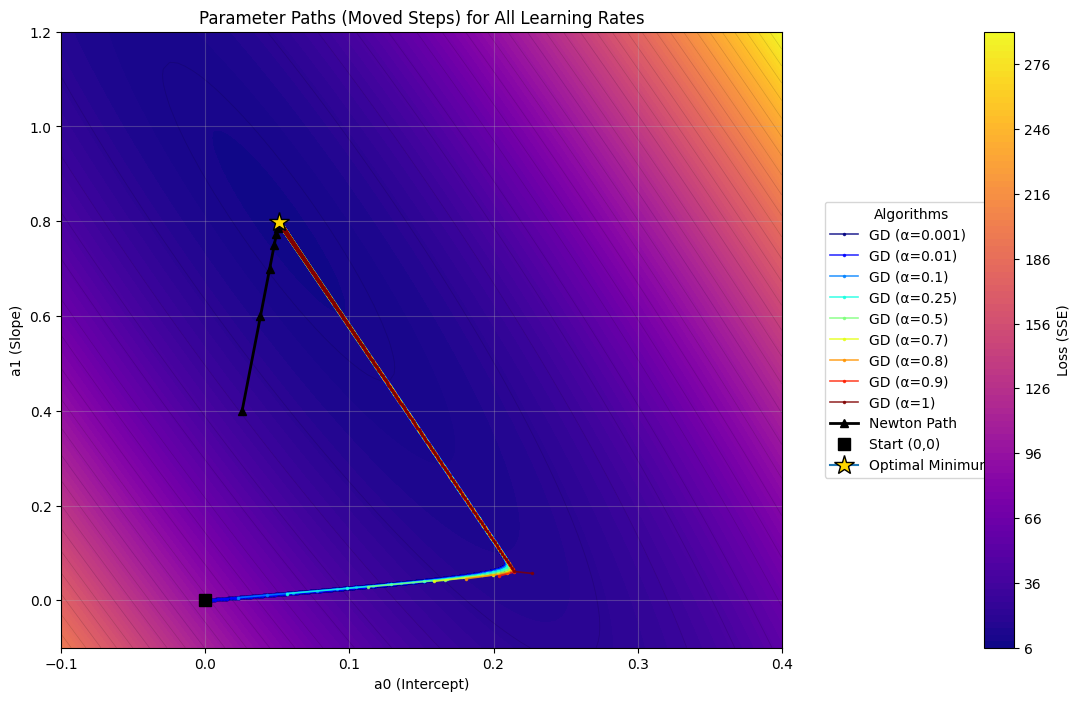

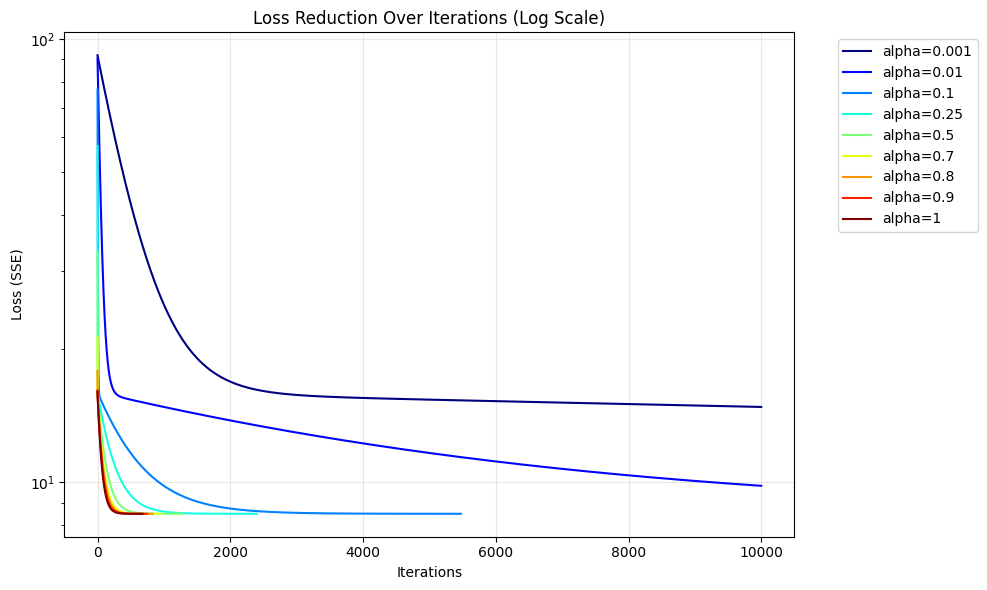

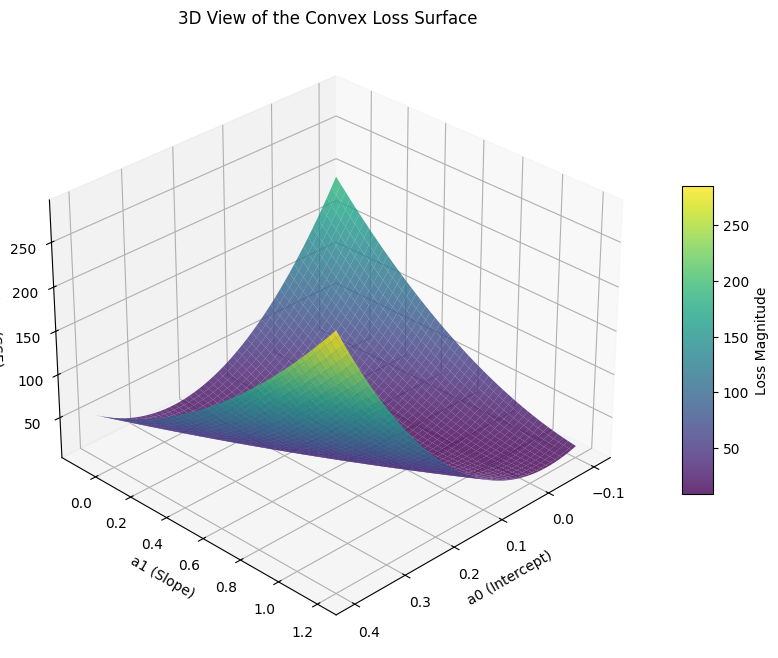

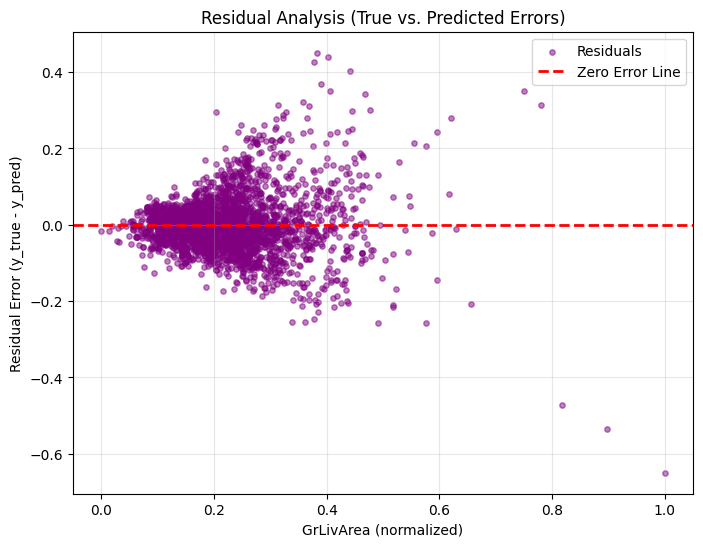

In [ ]:
# Comprehensive Visualizations (Complete)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Extract Newton's method parameter history
newton_params = np.array(n_param_hist)

# Create the grid for the Loss Surface Contour (A0 and A1)
a0_vals = np.linspace(-0.1, 0.4, 100)
a1_vals = np.linspace(-0.1, 1.2, 100)
A0, A1 = np.meshgrid(a0_vals, a1_vals)

# Calculate the loss (Loss_Surface) for every point on the grid
Loss_Surface = np.zeros_like(A0)
for i in range(A0.shape[0]):
    for j in range(A0.shape[1]):
        Loss_Surface[i, j] = loss_function(A0[i, j], A1[i, j], x_norm, y_norm)

# ---------------------------------------------------------
# Plot 1: Speed of Convergence across all Alphas
# ---------------------------------------------------------
converged_alphas = [str(alpha) for alpha in alphas]
iterations = [gd_results[alpha]['iterations'] for alpha in alphas]

plt.figure(figsize=(10, 5))
plt.bar(converged_alphas, iterations, color='skyblue', edgecolor='black')
plt.xlabel('Learning Rate (Alpha)')
plt.ylabel('Iterations to Converge')
plt.title('Speed of Convergence (Iterations) vs. Learning Rate')
plt.grid(axis='y', alpha=0.3)
plt.show()

# ---------------------------------------------------------
# Plot 2: Data with the Fitted Regression Line
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
# Plot the normalized data
plt.scatter(x_norm, y_norm, alpha=0.4, s=10, marker="x", color="green", label="Normalized Data")

# Get the best parameters (using GD with alpha=1.0)
best_a0 = gd_results[1]['a0']
best_a1 = gd_results[1]['a1']

# Generate line points
x_line = np.linspace(0, 1, 100)
y_line = best_a0 + best_a1 * x_line

# Plot the fitted line
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Fitted Line: y = {best_a0:.3f} + {best_a1:.3f}x')
plt.xlabel('GrLivArea (normalized)')
plt.ylabel('SalePrice (normalized)')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ---------------------------------------------------------
# Plot 3: Moved Steps (Parameter Paths) for ALL Alphas (Enhanced)
# ---------------------------------------------------------
# Make the figure wider to accommodate the legend
fig, ax = plt.subplots(figsize=(14, 8))

# Draw the FILLED contour background edge-to-edge
# Using levels=100 creates a very smooth, seamless gradient across ALL loss values
# 'plasma' gives a beautiful purple-to-yellow gradient (different from the blue photo)
cpf = ax.contourf(A0, A1, Loss_Surface, levels=100, cmap='plasma')

# Optional: Draw very faint black lines over the colors to outline the bowl shape
ax.contour(A0, A1, Loss_Surface, levels=30, colors='black', alpha=0.15, linewidths=0.5)

# Add the colorbar connected to the filled contour (cpf)
plt.colorbar(cpf, label='Loss (SSE)', ax=ax, pad=0.02)

# Generate distinct colors for each alpha
colors = cm.jet(np.linspace(0, 1, len(alphas)))

# Plot the path for every single alpha
for idx, alpha in enumerate(alphas):
    path = np.array(gd_results[alpha]['param_history'])
    # Thinner lines and alpha=0.8 so overlapping paths blend instead of hiding each other
    ax.plot(path[:, 0], path[:, 1], '.-', label=f'GD (α={alpha})', 
            color=colors[idx], markersize=3, linewidth=1.2, alpha=0.8)

# Overlay Newton's Method Path (zorder=10 ensures it draws ON TOP of the other lines)
ax.plot(newton_params[:, 0], newton_params[:, 1], 'k^-', 
        label='Newton Path', markersize=6, linewidth=2, zorder=10)

# Mark start point (zorder=11 ensures it is the very top layer)
ax.plot(0, 0, 'ks', label='Start (0,0)', markersize=8, zorder=11)

# Add a gold star at the final optimal point (like the reference photo)
ax.plot(newton_params[-1, 0], newton_params[-1, 1], marker='*', markersize=15, 
        markerfacecolor='gold', markeredgecolor='black', label='Optimal Minimum', zorder=12)

ax.set_title('Parameter Paths (Moved Steps) for All Learning Rates')
ax.set_xlabel('a0 (Intercept)')
ax.set_ylabel('a1 (Slope)')
ax.grid(True, alpha=0.3)

# Shrink current axis by 20% to make room for the legend on the right
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Place legend completely outside the plot area
ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Algorithms")

plt.show()

# ---------------------------------------------------------
# Plot 4: Loss over Iterations for ALL Alphas
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for idx, alpha in enumerate(alphas):
    # Log scale is better to see the exact drop in loss for all alphas
    plt.plot(gd_results[alpha]['loss_history'], label=f'alpha={alpha}', color=colors[idx], linewidth=1.5)

plt.title('Loss Reduction Over Iterations (Log Scale)')
plt.xlabel('Iterations')
plt.ylabel('Loss (SSE)')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot 5: 3D View of the Loss Surface
# ---------------------------------------------------------
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(A0, A1, Loss_Surface, cmap='viridis', alpha=0.8, edgecolor='none')

ax.set_title('3D View of the Convex Loss Surface')
ax.set_xlabel('a0 (Intercept)')
ax.set_ylabel('a1 (Slope)')
ax.set_zlabel('Loss (SSE)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Loss Magnitude')

# Adjust viewing angle for best perspective
ax.view_init(elev=30, azim=45)
plt.show()

# ---------------------------------------------------------
# Plot 6: Residual Analysis
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# Calculate the final predictions using the best parameters
predictions = best_a0 + best_a1 * x_norm
residuals = y_norm - predictions

# Plot True vs Predicted errors
plt.scatter(x_norm, residuals, alpha=0.5, s=15, color='purple', label='Residuals')
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

plt.title('Residual Analysis (True vs. Predicted Errors)')
plt.xlabel('GrLivArea (normalized)')
plt.ylabel('Residual Error (y_true - y_pred)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
